In [1]:
# Run in one cell (Colab)
!pip install --upgrade pip
!pip install webdataset huggingface-hub opencv-python-headless pillow tqdm
# optional if you want facenet later:
!pip install facenet-pytorch decord


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [webdataset]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 50.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 131.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 117.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 24.2 MB/s  0:00:18
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 57.7 MB/s  0:00:05
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 113.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 116.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 35.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 17.5 MB/s  0:00:21
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
#!/usr/bin/env python3
"""
build_balanced_subset_fast.py

Faster balanced subset builder for WildDeepfake WebDataset shards.
Strategy:
 - get list of shard paths from HF
 - shuffle shard list
 - open one shard URL at a time and stream only that shard
 - extract faces and save crops, increment counts
 - stop immediately when targets are reached

Usage:
  python build_balanced_subset_fast.py

Dependencies:
  pip install webdataset huggingface-hub opencv-python-headless pillow tqdm
"""
import os, time, random
from huggingface_hub import HfFileSystem, get_token, hf_hub_url
import webdataset as wds
from PIL import Image
import numpy as np
import cv2
from tqdm import tqdm

# ------------- USER CONFIG -------------
OUT_DIR = "wild_balanced_subset_fast"
TRAIN_PER_CLASS = 15000    # desired number per class in train
VAL_PER_CLASS = 2000      # desired number per class in val
TARGET_FRAMES_PER_VIDEO = 5
SAVE_QUALITY = 90
MAX_SHARDS_TO_TRY = 400   # try at most this many shards (set to None to allow all)
PRINT_EVERY = 200         # print status every N images seen overall
# adjust face detect sensitivity to increase hit rate (higher chance to find faces)
MIN_NEIGHBORS = 3
MIN_FACE_SIZE = (24,24)
# ---------------------------------------

# ensure output dirs exist
for split in ("train","val"):
    for cls in ("real","fake"):
        os.makedirs(os.path.join(OUT_DIR, split, cls), exist_ok=True)

# robust label inference (same approach as before)
def infer_label_from_sample(sample):
    def _to_str(v):
        if v is None: return ""
        if isinstance(v, bytes):
            try: return v.decode("utf-8", errors="ignore").lower()
            except: return str(v).lower()
        if isinstance(v, (list, tuple)) and len(v)>0: return _to_str(v[0])
        try:
            import numpy as _np
            if isinstance(v, _np.generic): v = v.item()
        except Exception:
            pass
        return str(v).lower()
    for k in ("label","label_name","label_str","labels","is_fake","is_real","fake","real"):
        if k in sample and sample[k] is not None:
            s = _to_str(sample[k])
            if s in ("0","real","r","false","f"): return "real"
            if s in ("1","fake","f","true","t"): return "fake"
    if "__key__" in sample:
        k = _to_str(sample["__key__"])
        if "real" in k and "fake" not in k: return "real"
        if "fake" in k and "real" not in k: return "fake"
    for v in sample.values():
        s = _to_str(v)
        if "real" in s and "fake" not in s: return "real"
        if "fake" in s and "real" not in s: return "fake"
        if s == "0": return "real"
        if s == "1": return "fake"
    return "fake"

# face detector
haar_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
if not os.path.exists(haar_path):
    raise RuntimeError(f"Haar cascade not found at {haar_path}")
face_cascade = cv2.CascadeClassifier(haar_path)

# Build list of shard files (train)
splits = {'train': '**/*_train/*.tar.gz'}
fs = HfFileSystem()
print("Resolving shard file list from Hugging Face (may take a few seconds)...")
files = [fs.resolve_path(p) for p in fs.glob("hf://datasets/xingjunm/WildDeepfake/" + splits["train"])]
print("Found", len(files), "train shard entries")

# shuffle shards to sample variety early
random.shuffle(files)

# counters & targets
counts = {"train": {"real":0,"fake":0}, "val": {"real":0,"fake":0}}
TARGETS = {"train": {"real":TRAIN_PER_CLASS,"fake":TRAIN_PER_CLASS}, "val": {"real":VAL_PER_CLASS,"fake":VAL_PER_CLASS}}

def done():
    for s in ("train","val"):
        for c in ("real","fake"):
            if counts[s][c] < TARGETS[s][c]:
                return False
    return True

seen_total = 0
saved_total = 0
video_idx = 0
start = time.time()

# process shards one-by-one
shards_tried = 0
for fileinfo in files:
    if MAX_SHARDS_TO_TRY and shards_tried >= MAX_SHARDS_TO_TRY:
        print("Reached MAX_SHARDS_TO_TRY:", MAX_SHARDS_TO_TRY)
        break
    shards_tried += 1

    # build single-shard curl pipe URL
    url = hf_hub_url(fileinfo.repo_id, fileinfo.path_in_repo, repo_type="dataset")
    urls_cmd = f"pipe: curl -s -L -H 'Authorization: Bearer {get_token()}' {url}"
    # create a WebDataset for that single shard
    ds = wds.WebDataset(urls_cmd).decode("pil")
    print(f"Processing shard {shards_tried}/{len(files)}: {fileinfo.path_in_repo}")

    # iterate samples from this single shard only
    for sample in ds:
        seen_total += 1
        # occasionally print status
        if seen_total % PRINT_EVERY == 0:
            elapsed = time.time() - start
            print(f"[seen={seen_total}] saved={saved_total} counts={counts} elapsed={elapsed:.1f}s")
        # early exit if done
        if done():
            break

        # find a PIL image field
        pil_img = None
        for k in ("jpg","png","image"):
            if k in sample and isinstance(sample[k], Image.Image):
                pil_img = sample[k]; break
        if pil_img is None:
            for v in sample.values():
                if isinstance(v, Image.Image):
                    pil_img = v; break
        if pil_img is None:
            continue

        label = infer_label_from_sample(sample)
        # decide split - prefer fill train first, then val
        if counts["train"][label] < TARGETS["train"][label]:
            split = "train"
        elif counts["val"][label] < TARGETS["val"][label]:
            split = "val"
        else:
            continue

        # detect face (faster, permissive settings)
        try:
            arr = np.array(pil_img.convert("RGB"))
            gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
            faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=MIN_NEIGHBORS, minSize=MIN_FACE_SIZE)
            if len(faces) == 0:
                # fallback: optionally save center crop if you want more positives — currently skip
                continue
            x,y,w,h = sorted(faces, key=lambda r: r[2]*r[3], reverse=True)[0]
            crop = arr[y:y+h, x:x+w]
            if crop is None or crop.size==0:
                continue
            pil_crop = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)).resize((224,224))
        except Exception:
            continue

        # save image
        vid = None
        if "__key__" in sample:
            try: vid = str(sample["__key__"]).replace("/","_")
            except: vid = None
        if vid is None:
            vid = f"v{video_idx}"; video_idx += 1
        out_dir = os.path.join(OUT_DIR, split, label)
        os.makedirs(out_dir, exist_ok=True)
        fname = f"{vid}_{seen_total}.jpg"
        out_path = os.path.join(out_dir, fname)
        i = 0
        while os.path.exists(out_path):
            i += 1
            out_path = os.path.join(out_dir, f"{vid}_{seen_total}_{i}.jpg")
        try:
            pil_crop.save(out_path, format="JPEG", quality=SAVE_QUALITY)
        except Exception:
            continue

        counts[split][label] += 1
        saved_total += 1

        # if we've reached both train targets for this class early, optionally break inner loop to go to next shard
        # but overall we check 'done' above.

    # after finishing this shard, if done stop entirely
    if done():
        print("Done: reached all targets.")
        break

elapsed = time.time() - start
print("="*40)
print("Finished.")
print("Shards tried:", shards_tried)
print("Seen samples:", seen_total)
print("Saved crops:", saved_total)
print("Counts:", counts)
print("Time elapsed:", elapsed)
print("="*40)


Resolving shard file list from Hugging Face (may take a few seconds)...
Found 963 train shard entries
Processing shard 1/963: deepfake_in_the_wild/real_train/31.tar.gz


/usr/local/lib/python3.12/dist-packages/webdataset/compat.py:379: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn("WebDataset(shardshuffle=...) is None; set explicitly to False or a number")


Processing shard 2/963: deepfake_in_the_wild/fake_train/402.tar.gz
[seen=200] saved=143 counts={'train': {'real': 1, 'fake': 142}, 'val': {'real': 0, 'fake': 0}} elapsed=7.8s
[seen=400] saved=342 counts={'train': {'real': 1, 'fake': 341}, 'val': {'real': 0, 'fake': 0}} elapsed=13.2s
[seen=600] saved=542 counts={'train': {'real': 1, 'fake': 541}, 'val': {'real': 0, 'fake': 0}} elapsed=19.9s
[seen=800] saved=742 counts={'train': {'real': 1, 'fake': 741}, 'val': {'real': 0, 'fake': 0}} elapsed=25.2s
[seen=1000] saved=928 counts={'train': {'real': 1, 'fake': 927}, 'val': {'real': 0, 'fake': 0}} elapsed=30.6s
[seen=1200] saved=1118 counts={'train': {'real': 1, 'fake': 1117}, 'val': {'real': 0, 'fake': 0}} elapsed=36.2s
[seen=1400] saved=1318 counts={'train': {'real': 1, 'fake': 1317}, 'val': {'real': 0, 'fake': 0}} elapsed=42.5s
[seen=1600] saved=1518 counts={'train': {'real': 1, 'fake': 1517}, 'val': {'real': 0, 'fake': 0}} elapsed=48.1s
[seen=1800] saved=1704 counts={'train': {'real': 1, 

Showing up to 8 samples:
wild_balanced_subset_fast/train/real/._417_real_131_1978_45531.jpg


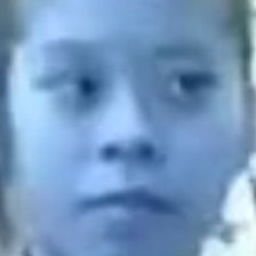

wild_balanced_subset_fast/train/fake/._509_fake_154_3300_9684.jpg


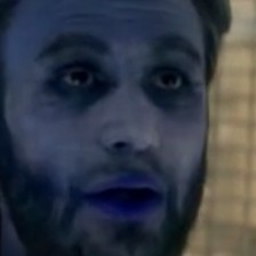

wild_balanced_subset_fast/val/real/._112_real_399_5211_62367.jpg


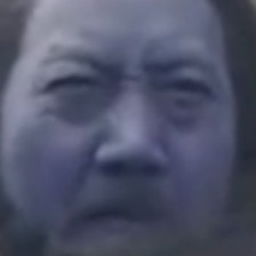

wild_balanced_subset_fast/val/fake/._308_fake_6_572_30582.jpg


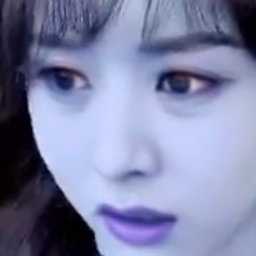

In [2]:
from IPython.display import display
from PIL import Image
import random, os

root = "wild_balanced_subset_fast"  # change to the discovered absolute path if needed
cands = []
for split in ("train","val"):
    for lab in ("real","fake"):
        d = os.path.join(root, split, lab)
        if os.path.exists(d):
            f = os.listdir(d)
            if f:
                cands.append(os.path.join(d, random.choice(f)))
print("Showing up to 8 samples:")
for p in cands[:8]:
    print(p)
    display(Image.open(p).resize((256,256)))


In [3]:
!pip install torch torchvision sklearn tqdm


  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
ERROR: Failed to build 'sklearn' when getting requirements to build wheel


In [4]:
#!/usr/bin/env python3
"""
train_f3_small.py

Compact F3-style trainer for the balanced dataset created in `wild_balanced_subset_fast`.

Usage:
    python train_f3_small.py

Edit config at top as needed.
"""
import os
import time
import random
from glob import glob
from collections import defaultdict

import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models

from sklearn.metrics import roc_auc_score, accuracy_score

# -------------------- CONFIG --------------------
DATA_ROOT = "wild_balanced_subset_fast"  # root with train/val subfolders
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR = os.path.join(DATA_ROOT, "val")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4
EPOCHS = 10
LR = 2e-4
WEIGHT_DECAY = 1e-5
PRETRAINED_BACKBONE = True          # EfficientNet-B0 pretrained on ImageNet
SAVE_DIR = "checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

PRINT_EVERY = 50
# ------------------------------------------------

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

# -------------------- DATA --------------------
# transforms for spatial branch
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1,0.1,0.1,0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE*1.1)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# We'll also need the raw image for FFT branch, so we'll create a small wrapper dataset
class FFTImageFolder(datasets.ImageFolder):
    """
    Extends ImageFolder to also return an FFT magnitude tensor for each image.
    FFT computed on grayscale resized to IMG_SIZE.
    """
    def __init__(self, root, transform=None, fft_transform=None):
        super().__init__(root, transform=transform)
        self.fft_transform = fft_transform

    def __getitem__(self, index):
        path, target = self.samples[index]
        # load PIL image
        sample = self.loader(path)
        if self.transform is not None:
            img = self.transform(sample)
        else:
            img = transforms.ToTensor()(sample)
        # FFT: compute on grayscale resized image for frequency branch
        if self.fft_transform is not None:
            gray_pil = transforms.functional.to_grayscale(transforms.functional.resize(sample, (IMG_SIZE, IMG_SIZE)))
            gray_tensor = transforms.ToTensor()(gray_pil).squeeze(0)  # [H,W]
            fft_mag = self._compute_fft_mag(gray_tensor)  # returns 1xHxW tensor
        else:
            fft_mag = None
        # return img tensor, fft tensor, class, and filepath (for video aggregation)
        return img, fft_mag, target, path

    @staticmethod
    def _compute_fft_mag(gray_tensor):
        # gray_tensor: HxW (float32 [0,1])
        arr = gray_tensor.numpy()
        # 2D FFT
        f = np.fft.fft2(arr)
        fshift = np.fft.fftshift(f)
        mag = np.abs(fshift)
        # log scale
        mag = np.log1p(mag)
        # normalize to 0..1
        mag = (mag - mag.min()) / (mag.max() - mag.min() + 1e-8)
        mag = mag.astype(np.float32)
        # to torch tensor [1,H,W]
        return torch.from_numpy(mag).unsqueeze(0)

# build datasets
train_dataset = FFTImageFolder(TRAIN_DIR, transform=train_transform, fft_transform=True)
val_dataset = FFTImageFolder(VAL_DIR, transform=val_transform, fft_transform=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

num_classes = len(train_dataset.classes)
print("Classes:", train_dataset.classes)
print("Train / Val sizes:", len(train_dataset), len(val_dataset))

# -------------------- MODEL --------------------
class FreqBranch(nn.Module):
    """Small CNN for frequency magnitude input (1xHxW)"""
    def __init__(self, out_features=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, 2, 1), nn.BatchNorm2d(16), nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, 3, 2, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, 2, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(64, out_features)

    def forward(self, x):
        # x: [B,1,H,W]
        z = self.net(x).view(x.size(0), -1)
        z = self.fc(z)
        return z

class F3Net(nn.Module):
    def __init__(self, backbone_name="efficientnet_b0", feat_dim=256, freq_dim=128, pretrained=True):
        super().__init__()
        # backbone from torchvision (EfficientNet-B0)
        if backbone_name == "efficientnet_b0":
            backbone = models.efficientnet_b0(pretrained=pretrained)
            # remove classifier, keep features
            self.backbone = backbone.features
            backbone_out_dim = 1280  # EfficientNet-B0 final channels before classifier
        else:
            raise NotImplementedError("Only efficientnet_b0 is implemented in this script.")
        # pooling & head for backbone
        self.spatial_pool = nn.AdaptiveAvgPool2d(1)
        self.spatial_fc = nn.Linear(backbone_out_dim, feat_dim)

        # frequency branch
        self.freq_branch = FreqBranch(out_features=freq_dim)

        # fusion head
        fusion_dim = feat_dim + freq_dim
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim//2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(fusion_dim//2, 1),
        )

    def forward(self, img, fft_mag):
        # img: [B,3,H,W] normalized
        # fft_mag: [B,1,H,W] in 0..1
        x = self.backbone(img)            # [B, C, H', W']
        x = self.spatial_pool(x).view(x.size(0), -1)  # [B, C]
        x = self.spatial_fc(x)           # [B, feat_dim]

        f = self.freq_branch(fft_mag)    # [B, freq_dim]
        z = torch.cat([x, f], dim=1)     # [B, fusion_dim]
        logits = self.classifier(z).squeeze(1)
        return logits

# instantiate model
model = F3Net(pretrained=PRETRAINED_BACKBONE).to(DEVICE)

# -------------------- OPTIMIZER / LOSS --------------------
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.BCEWithLogitsLoss()

# -------------------- TRAIN / EVAL HELPERS --------------------
def sigmoid(x): return 1.0 / (1.0 + np.exp(-x))

def train_one_epoch(epoch):
    model.train()
    losses = []
    y_true = []
    y_prob = []
    loop = tqdm(train_loader, desc=f"Train Epoch {epoch}")
    for i, (imgs, ffts, labels, paths) in enumerate(loop):
        imgs = imgs.to(DEVICE)
        # ffts is list of tensors or None in batch (we ensured it's tensor)
        ffts = torch.stack([t if t is not None else torch.zeros(1, IMG_SIZE, IMG_SIZE) for t in ffts])
        ffts = ffts.to(DEVICE)
        labels = labels.float().to(DEVICE)

        optimizer.zero_grad()
        logits = model(imgs, ffts)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        y_prob.extend(probs.tolist())
        y_true.extend(labels.cpu().numpy().tolist())

        if (i+1) % PRINT_EVERY == 0:
            loop.set_postfix(loss=np.mean(losses[-PRINT_EVERY:]))

    # metrics
    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = float("nan")
    acc = accuracy_score((np.array(y_prob)>0.5).astype(int), np.array(y_true).astype(int))
    return np.mean(losses), auc, acc

def validate(epoch):
    model.eval()
    losses = []
    y_true = []
    y_prob = []
    # for video-level aggregation
    vid_probs = defaultdict(list)
    vid_labels = {}

    with torch.no_grad():
        loop = tqdm(val_loader, desc=f"Val Epoch {epoch}")
        for imgs, ffts, labels, paths in loop:
            imgs = imgs.to(DEVICE)
            ffts = torch.stack([t if t is not None else torch.zeros(1, IMG_SIZE, IMG_SIZE) for t in ffts]).to(DEVICE)
            labels = labels.float().to(DEVICE)

            logits = model(imgs, ffts)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            losses.append(loss.item())
            y_prob.extend(probs.tolist())
            y_true.extend(labels.cpu().numpy().tolist())

            # aggregate by video id inferred from filename prefix (split by '_' and take first token)
            for pth, pr, lab in zip(paths, probs, labels.cpu().numpy()):
                fname = os.path.basename(pth)
                vid = fname.split("_")[0]
                vid_probs[vid].append(float(pr))
                vid_labels[vid] = int(lab)

    # frame-level metrics
    try:
        auc_frame = roc_auc_score(y_true, y_prob)
    except Exception:
        auc_frame = float("nan")
    acc_frame = accuracy_score((np.array(y_prob)>0.5).astype(int), np.array(y_true).astype(int))

    # video-level aggregation
    vids = sorted(vid_probs.keys())
    v_true = []
    v_prob = []
    for v in vids:
        v_true.append(vid_labels[v])
        v_prob.append(float(np.mean(vid_probs[v])))
    try:
        auc_video = roc_auc_score(v_true, v_prob)
    except Exception:
        auc_video = float("nan")
    acc_video = accuracy_score((np.array(v_prob)>0.5).astype(int), np.array(v_true).astype(int))

    return np.mean(losses), auc_frame, acc_frame, auc_video, acc_video

# -------------------- MAIN TRAIN LOOP --------------------
best_video_auc = -1
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    train_loss, train_auc, train_acc = train_one_epoch(epoch)
    val_loss, val_auc_frame, val_acc_frame, val_auc_video, val_acc_video = validate(epoch)
    t1 = time.time()
    print(f"Epoch {epoch}/{EPOCHS}  time {(t1-t0):.1f}s")
    print(f"  Train loss: {train_loss:.4f}  AUC: {train_auc:.4f}  Acc: {train_acc:.4f}")
    print(f"  Val   loss: {val_loss:.4f}  Frame AUC: {val_auc_frame:.4f} Acc: {val_acc_frame:.4f}")
    print(f"                 Video AUC: {val_auc_video:.4f} Acc: {val_acc_video:.4f}")

    # save checkpoint if better video-level AUC
    if val_auc_video > best_video_auc:
        best_video_auc = val_auc_video
        ckpt_path = os.path.join(SAVE_DIR, f"best_epoch_{epoch}_vidAUC_{val_auc_video:.4f}.pth")
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_auc_video": val_auc_video,
        }, ckpt_path)
        print("Saved checkpoint:", ckpt_path)

print("Training finished. Best video AUC:", best_video_auc)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You 

Classes: ['fake', 'real']
Train / Val sizes: 30000 4000


100%|██████████| 20.5M/20.5M [00:00<00:00, 143MB/s]
Val Epoch 1:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
Val Epoch 1: 100%|██████████| 125/125 [00:20<00:00,  6.25it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Epoch 1/10  time 323.0s
  Train loss: 0.0709  AUC: 0.9969  Acc: 0.9728
  Val   loss: 2.2295  Frame AUC: 0.5613 Acc: 0.5377
                 Video AUC: nan Acc: 0.0000


Train Epoch 2:   0%|          | 0/938 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
Val Epoch 2:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/fr

...

Train Epoch 9:   0%|          | 0/938 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
Val Epoch 9:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/fr

Epoch 9/10  time 326.0s
  Train loss: 0.0057  AUC: 1.0000  Acc: 0.9980
  Val   loss: 2.1339  Frame AUC: 0.7180 Acc: 0.6148
                 Video AUC: nan Acc: 1.0000


Train Epoch 10:   0%|          | 0/938 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
Val Epoch 10:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/

Epoch 10/10  time 328.2s
  Train loss: 0.0058  AUC: 1.0000  Acc: 0.9985
  Val   loss: 2.0857  Frame AUC: 0.7574 Acc: 0.6518
                 Video AUC: nan Acc: 1.0000
Training finished. Best video AUC: -1



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [5]:
# diagnostics: check per-video label distribution used during validation
from collections import defaultdict
import os, glob

val_root = "wild_balanced_subset_fast/val"
vid_labels = {}
for cls in ("real","fake"):
    d = os.path.join(val_root, cls)
    for f in os.listdir(d):
        vid = f.split("_")[0]
        # map label name to int: fake->1, real->0 (same as training script)
        vid_labels[vid] = 1 if cls=="fake" else 0

from collections import Counter
cnt = Counter(vid_labels.values())
print("Per-video label counts (val):", cnt)   # if one key present -> AUC nan
print("Number of unique videos in val:", len(vid_labels))

# Also check frame-level distribution in val
frame_counts = { "real": len(os.listdir(os.path.join(val_root,"real"))),
                 "fake": len(os.listdir(os.path.join(val_root,"fake"))) }
print("Frame-level counts (val):", frame_counts)


Per-video label counts (val): Counter({1: 1})
Number of unique videos in val: 1
Frame-level counts (val): {'real': 2000, 'fake': 2000}


In [6]:
# 1a) Run inference over val set (or reuse cached arrays if you already have them)
import torch, numpy as np, os
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

filepaths = []
y_true = []
y_prob = []
y_pred = []

with torch.no_grad():
    for imgs, ffts, labels, paths in tqdm(val_loader, desc="Infer val"):
        imgs = imgs.to(device)
        ffts = torch.stack([t if t is not None else torch.zeros(1, IMG_SIZE, IMG_SIZE) for t in ffts]).to(device)
        logits = model(imgs, ffts)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
        preds = (probs > 0.5).astype(int)
        y_prob.extend(probs.tolist())
        y_pred.extend(preds.tolist())
        y_true.extend(labels.numpy().astype(int).tolist())
        filepaths.extend(paths)

y_true = np.array(y_true)
y_prob = np.array(y_prob).ravel()
y_pred = np.array(y_pred).ravel()

print("Collected:", len(filepaths), "frames")
print("Frame label distribution:", dict(zip(*np.unique(y_true, return_counts=True))))


Infer val:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
Infer val: 100%|██████████| 125/125 [00:27<00:00,  4.62it/s]

Collected: 4000 frames
Frame label distribution: {0: 2000, 1: 2000}


In [7]:
# robust extractor: captures everything up to the final underscore-number before extension
import re
from collections import defaultdict, Counter

def extract_vid_from_filename(fname):
    # matches "...<videoid>_<number>.jpg" possibly with extra numeric suffixes
    # group 1 is the video id portion
    m = re.match(r"^(.+?)_(\d+)(?:_\d+)?\.(jpg|jpeg|png)$", fname, flags=re.IGNORECASE)
    if m:
        return m.group(1)
    # fallback: remove extension and return all except last token if last is numeric
    base = os.path.splitext(fname)[0]
    parts = base.split("_")
    if len(parts) > 1 and parts[-1].isdigit():
        return "_".join(parts[:-1])
    # last fallback: return base
    return base

# Build mapping
vid_probs = defaultdict(list)
vid_labels = {}
for fp, pr, lab in zip(filepaths, y_prob, y_true):
    fname = os.path.basename(fp)
    vid = extract_vid_from_filename(fname)
    vid_probs[vid].append(float(pr))
    vid_labels[vid] = int(lab)

vid_counts = Counter(vid_labels.values())
print("Per-video label counts (val):", vid_counts)
print("Unique videos in val:", len(vid_probs))


Per-video label counts (val): Counter({1: 29, 0: 20})
Unique videos in val: 49


Frame-level classification report:
              precision    recall  f1-score   support

        real       0.72      0.50      0.59      2000
        fake       0.62      0.80      0.70      2000

    accuracy                           0.65      4000
   macro avg       0.67      0.65      0.64      4000
weighted avg       0.67      0.65      0.64      4000

Saved frame_confusion_matrix.png
Saved frame_roc_curve.png (AUC=0.7574)


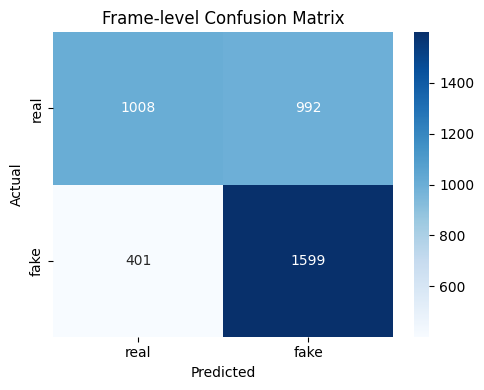

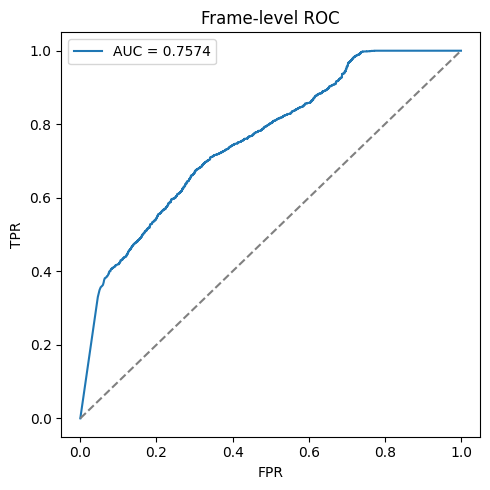

In [8]:
# install seaborn if missing: uncomment next line
# !pip install seaborn

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, classification_report

# Frame-level
print("Frame-level classification report:")
print(classification_report(y_true, y_pred, target_names=["real","fake"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["real","fake"], yticklabels=["real","fake"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Frame-level Confusion Matrix")
plt.tight_layout(); plt.savefig("frame_confusion_matrix.png", dpi=200)
print("Saved frame_confusion_matrix.png")

if len(np.unique(y_true)) > 1:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(5,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("Frame-level ROC")
    plt.legend(); plt.tight_layout(); plt.savefig("frame_roc_curve.png", dpi=200)
    print(f"Saved frame_roc_curve.png (AUC={auc:.4f})")
else:
    print("Frame-level ROC skipped: only one class present.")


Video-level label distribution: {0: 20, 1: 29}
Video-level classification report:
              precision    recall  f1-score   support

        real       0.67      0.50      0.57        20
        fake       0.71      0.83      0.76        29

    accuracy                           0.69        49
   macro avg       0.69      0.66      0.67        49
weighted avg       0.69      0.69      0.68        49

Saved video_confusion_matrix.png
Saved video_roc_curve.png (AUC=0.7603)


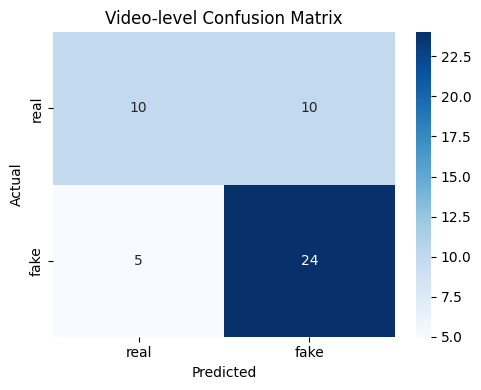

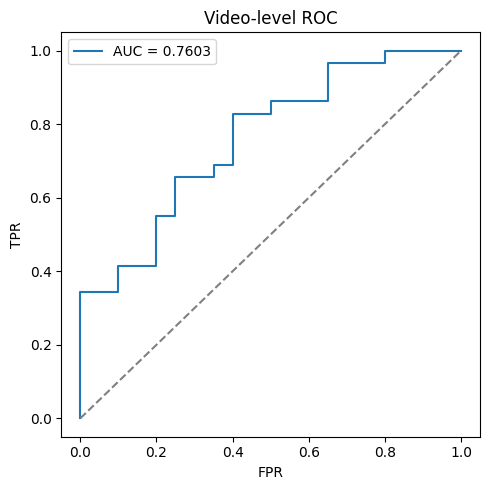

In [9]:
# aggregate by video (mean of frame probs)
vids = sorted(vid_probs.keys())
v_probs = np.array([np.mean(vid_probs[v]) for v in vids])
v_true = np.array([vid_labels[v] for v in vids]).astype(int)
v_pred = (v_probs > 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
print("Video-level label distribution:", dict(zip(*np.unique(v_true, return_counts=True))))
print("Video-level classification report:")
print(classification_report(v_true, v_pred, target_names=["real","fake"]))

# confusion matrix
cmv = confusion_matrix(v_true, v_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cmv, annot=True, fmt="d", cmap="Blues", xticklabels=["real","fake"], yticklabels=["real","fake"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Video-level Confusion Matrix")
plt.tight_layout(); plt.savefig("video_confusion_matrix.png", dpi=200)
print("Saved video_confusion_matrix.png")

# ROC
if len(np.unique(v_true)) > 1:
    fpr, tpr, _ = roc_curve(v_true, v_probs)
    auc = roc_auc_score(v_true, v_probs)
    plt.figure(figsize=(5,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("Video-level ROC")
    plt.legend(); plt.tight_layout(); plt.savefig("video_roc_curve.png", dpi=200)
    print(f"Saved video_roc_curve.png (AUC={auc:.4f})")
else:
    print("Video-level ROC skipped: only one class present in video labels.")
